# Data Access and Setup
The dataset includes approximately **4.2 million records**. Due to size constraints, raw data is not hosted on GitHub. To reproduce this analysis from raw data, follow the steps below.

**You only need to complete these steps if you want to reproduce the analysis from raw data.**

1. Remove Parquet File: You will need to delete the 'all_trips_v2_processed.parquet' file from the '02_processed_data' directory. This file was compiled after the data was cleaned and processed. If it is present, the code will use it instead of the raw data.
2. Access Raw Data:
    * [zip file](https://drive.google.com/file/d/1UI4Ou2bHVS-NbilmWFvzcEy-Og_hKEyS/view?usp=drive_link): You can download the specific raw CSVs used in this analysis from my Google Drive.
    * [official source](https://divvy-tripdata.s3.amazonaws.com/index.html): Alternatively, you can download the raw data directly from the official source in compliance with [their license](https://divvybikes.com/data-license-agreement).

# Cyclistic Case Study: How Does a Bike-Share Navigate Speedy Success?
## Phase 1: Ask

### Business Task
The primary objective is to analyze historical trip data to identify how **annual members** and **casual riders** use Cyclistic bikes differently. These insights will be used to design a new marketing strategy aimed at converting casual riders into profitable annual members.

### Key Stakeholders
* **Lily Moreno:** Director of Marketing and my manager.
* **Cyclistic Executive Team:** The team responsible for approving the final marketing program.
* **Marketing Analytics Team:** My peers who collect and report data to guide strategy.

### Guiding Questions
* How do annual members and casual riders use Cyclistic bikes differently?
* How can insights drive business decisions?
* What is the most effective way to influence casual riders to become members via digital media?

## Phase 2: Prepare

### Data Sources
* **Dataset:** 15 total months of historical trip data (Q1 2019-Q1 2020) from Cyclistic (fictional name for Motivate International Inc. data)
* **Organization:** The data is provided in CSV format, containing details such as start/end times, station names, and rider type.
* **Bias & Credibility:** The data is primary, internal business data, ensuring high integrity and relevance (ROCCC).
* **Licensing & Privacy:** Data is public but anonymized; no personally identifiable information (PII) like credit card numbers is accessible.

In [17]:
# internal check to ensure requirements are installed
import importlib.util
packages = ["numpy", "pandas", "matplotlib", "seaborn", "pyarrow", "fastparquet"]
for pkg in packages:
    if importlib.util.find_spec(pkg) is None:
        print(f"Installing {pkg}...")
        %pip install {pkg}

# standard import and aliases
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# define the relative paths for data directories
raw_path = os.path.join("..", "01_raw_data")
processed_dir = os.path.join("..", "02_processed_data")

# ensure the processed directory exists
os.makedirs(processed_dir, exist_ok=True)

# define the path for the processed parquet file
parquet_file = os.path.join(processed_dir, "all_trips_v2_processed.parquet")

# check to see if parquet file is present
# load parquet file and set flag to True if so
# load csv files and set flag to False otherwise
if os.path.exists(parquet_file):
    print("Fully processed Parquet file found in 02_processed_data! Fetching data...")
    all_trips_v2 = pd.read_parquet(parquet_file)
    using_parquet = True 

else:
    print("Parquet file not found. Fetching raw CSVs from 01_raw_data...")
    
    file_names = [
        "trips_2019_q1_raw.csv",
        "trips_2019_q2_raw.csv",
        "trips_2019_q3_raw.csv",
        "trips_2019_q4_raw.csv",
        "trips_2020_q1_raw.csv"
    ]
    
    df_list = []
    for file in file_names:
        print(f"Fetching {file}...")
        df = pd.read_csv(os.path.join(raw_path, file), engine='pyarrow')
        df['source_file'] = file 
        df_list.append(df)
        
    using_parquet = False

Fully processed Parquet file found in 02_processed_data! Fetching data...


## Phase 3: Process

### Tools Used
I am using **Python** within a **Jupyter Notebook** for this project to handle large datasets efficiently and ensure the analysis is reproducible.

### Data Cleaning Steps
1. **Standardize Columns:**
    * Convert column names in each file to lowercase and strip whitespace.
    * Rename 2019 column names to match 2020 column names.
    * Convert data type of 2019 columns to match 2020.
1. **Merging:**
    * Combine each file into a single dataframe.
1. **Drop Columns:**
    * Remove unnecessary demographic data to align with privacy guidelines.
    * Remove data that was not collected in 2020 or irrelevant to the analysis.
1. **Transformation:**
    * Update 'member_casual' to only contain the values 'member' or 'casual'.
    * Convert 'started_at' and 'ended_at' from strings to datetime objects to enable calculations.
    * Add columns 'date', 'month', 'day', 'year', and 'day_of_week' for aggregation.
    * Add new 'ride_length' column which is 'ended_at' minus 'started_at'
1. **Filtering:** Only include rows where...
    * 'start_station_name' != "HQ QR"
    * 'ride_length' >= 0
    * 'ride_length' <= 86400 (24 hours = 86,400 seconds)

### Data Exploration Note
During initial exploration, I compared the columns of data types of the 5 raw CSV files. I discovered that the 2019 datasets used different column names (e.g., 'trip_id' versus 'ride_id', and Q2 2019 was completely different from the rest). Additionally, the 'ride_id' and 'rideable_type' columns were read as integers in 2019 but strings in 2020. The following cleaning loop standardizes these discrepancies so they can be merged successfully.

In [18]:
# determine if using parquet or not
# if not then standardize all data and convert 2019 data structure to match 2020 data structure
if not using_parquet:
    print("Standardizing, renaming, and cleaning raw dataframes...")
    cleaned_dfs = []

    # loop through the raw dataframes
    for df in df_list:
        file_source = df['source_file'].iloc[0]
        df.columns = df.columns.str.strip().str.lower()

        # rename columns of 2019 data to match 2020 data
        if "2019" in file_source:
            if "q2" in file_source:
                df = df.rename(columns={'01 - rental details rental id': 'ride_id', '01 - rental details bike id': 'rideable_type', '01 - rental details local start time': 'started_at', '01 - rental details local end time': 'ended_at', '03 - rental start station name': 'start_station_name', '03 - rental start station id': 'start_station_id', '02 - rental end station name': 'end_station_name', '02 - rental end station id': 'end_station_id', 'user type': 'member_casual'})
            else:
                df = df.rename(columns={'trip_id': 'ride_id', 'bikeid': 'rideable_type', 'start_time': 'started_at', 'end_time': 'ended_at', 'from_station_name': 'start_station_name', 'from_station_id': 'start_station_id', 'to_station_name': 'end_station_name', 'to_station_id': 'end_station_id', 'usertype': 'member_casual'})
            
            # convert specific columns to string to stack correctly with 2020
            df['ride_id'] = df['ride_id'].astype(str)
            df['rideable_type'] = df['rideable_type'].astype(str)

        # 'source_file' column is no longer needed now that cleaning is complete
        df = df.drop(columns=['source_file'])
        cleaned_dfs.append(df)
    
    # combine all the clean dataframes    
    all_trips = pd.concat(cleaned_dfs, axis=0, ignore_index=True)

    # remove unnecessary demographic data, data no longer collected in 2020, or data irrelevant to the analysis
    print("Dropping columns and converting data types...")
    all_trips = all_trips.drop(columns=['start_lat', 'start_lng', 'end_lat', 'end_lng', 'birthyear', 'gender',
    'tripduration', '01 - rental details duration in seconds uncapped', '05 - member details member birthday year', 'member gender'], errors='ignore')

    # reassign 'member_casual' values to either 'member' or 'casual'
    all_trips['member_casual'] = all_trips['member_casual'].replace({'Subscriber': 'member', 'Customer': 'casual'})

    # convert 'started_at' and 'ended_at' to datetime objects for calculations
    all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
    all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'])

    # add 'date', 'month', 'day', 'year', 'day_of_week', 'hour_clock', and 'ride_length' columns for further aggregation
    all_trips['date'] = all_trips['started_at'].dt.date
    all_trips['month'] = all_trips['started_at'].dt.strftime('%b')
    all_trips['day'] = all_trips['started_at'].dt.day
    all_trips['year'] = all_trips['started_at'].dt.year
    all_trips['day_of_week'] = all_trips['started_at'].dt.day_name()
    all_trips['hour_clock'] = all_trips['started_at'].dt.strftime('%I %p')
    all_trips['ride_length'] = (all_trips['ended_at'] - all_trips['started_at']).dt.total_seconds()

    # only include rows where 'start_station_name' != "HQ QR" (quality checks) AND 'ride_length' >= 0 AND 'ride_length' <= 86,400 seconds (24 hours)
    # assign to a new, updated dataframe since removing data
    all_trips_v2 = all_trips[(all_trips['start_station_name'] != "HQ QR") & 
                             (all_trips['ride_length'] >= 0) & 
                             (all_trips['ride_length'] <= 86400)].copy()

    # save as parquet to significantly decrease loading time
    all_trips_v2.to_parquet(parquet_file)
    print("Data fully cleaned, features engineered, and saved to Parquet in processed folder!")

else:
    print("Skipping processing phase; fully cleaned data already loaded from Parquet.")

# final head after cleaning
all_trips_v2.head()

Skipping processing phase; fully cleaned data already loaded from Parquet.


,ride_id,started_at,ended_at,rideable_type,start_station_id,start_station_name,end_station_id,end_station_name,member_casual,date,month,day,year,day_of_week,hour_clock,ride_length
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,199,Wabash Ave & Grand Ave,84.0,Milwaukee Ave & Grand Ave,member,2019-01-01,Jan,1,2019,Tuesday,12 AM,390.0
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,44,State St & Randolph St,624.0,Dearborn St & Van Buren St (*),member,2019-01-01,Jan,1,2019,Tuesday,12 AM,441.0
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,15,Racine Ave & 18th St,644.0,Western Ave & Fillmore St (*),member,2019-01-01,Jan,1,2019,Tuesday,12 AM,829.0
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,123,California Ave & Milwaukee Ave,176.0,Clark St & Elm St,member,2019-01-01,Jan,1,2019,Tuesday,12 AM,1783.0
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,173,Mies van der Rohe Way & Chicago Ave,35.0,Streeter Dr & Grand Ave,member,2019-01-01,Jan,1,2019,Tuesday,12 AM,364.0


## Phase 4: Analyze

### Analysis Summary
* Explore the relationship between number of rides and average trip duration for each rider type, on each day of the week.
* Compare monthly usage by rider type.
* Compare each rider types usage by hour of the day.
* Rank the most used stations

In [19]:
# 'ride_length' analysis (in seconds)
'''
print("\nStatistics for 'ride_length':\n")
display(all_trips_v2['ride_length'].describe())

# compare statistics grouped by 'member_casual'
print("\nStatistics grouped by 'member_casual':\n")
display(all_trips_v2.groupby('member_casual')['ride_length'].agg(['mean', 'median', 'max', 'min']))

# compare average ride time by each day, grouped by 'member_casual'
print("\nAverage ride length by rider type and day of the week:\n")
display(all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length'].mean())
'''

# order days of the week properly
days_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
all_trips_v2['day_of_week'] = pd.Categorical(all_trips_v2['day_of_week'], categories=days_order, ordered=True)

# order months properly
months_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
all_trips_v2['month'] = pd.Categorical(all_trips_v2['month'], categories=months_order, ordered=True)

# order hours properly
hour_order = [
    '12 AM', '01 AM', '02 AM', '03 AM', '04 AM', '05 AM', 
    '06 AM', '07 AM', '08 AM', '09 AM', '10 AM', '11 AM',
    '12 PM', '01 PM', '02 PM', '03 PM', '04 PM', '05 PM', 
    '06 PM', '07 PM', '08 PM', '09 PM', '10 PM', '11 PM'
]

all_trips_v2['hour_clock'] = pd.Categorical(all_trips_v2['hour_clock'], categories=hour_order, ordered=True)

# inspect
'''
print("\nAverage ride length (sorted by day of week):\n")
display(all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length'].mean())
'''
# analyze data by type and weekday
stats_by_type_and_weekday = all_trips_v2.groupby(['member_casual', 'day_of_week']).agg(
    number_of_rides = ('ride_id', 'count'),
    average_duration = ('ride_length', 'mean')
).reset_index()
# print("\nSummary of rides and duration by rider type and weekday:\n", stats_by_type_and_weekday)

# analyze peak monthly usage
stats_by_month = all_trips_v2.groupby(['month', 'member_casual']).agg(
    number_of_rides = ('ride_id', 'count')
).reset_index()
# print("\nMonthly Usage:\n", stats_by_month)

# analyze peak hourly usage
stats_by_hour = all_trips_v2.groupby(['hour_clock', 'member_casual']).agg(
    number_of_rides = ('ride_id', 'count')
).reset_index()
# print("\nHourly Usage:\n", stats_by_hour)

# analyze usage by start station
top_10_stations = all_trips_v2['start_station_name'].value_counts().nlargest(10)
# print("\nMost Used Start Stations:\n", top_10_stations)

## Phase 5: Share

### Key Findings
* **Visualization 1:** Day of Week Usage comparison.
* **Visualization 2:** Average ride duration.
* **Visualization 3:** Monthly usage comparison.
* **Visualization 4:** Hourly usage comparison.
* **Visualization 5:** Start Station Usage Top 10.

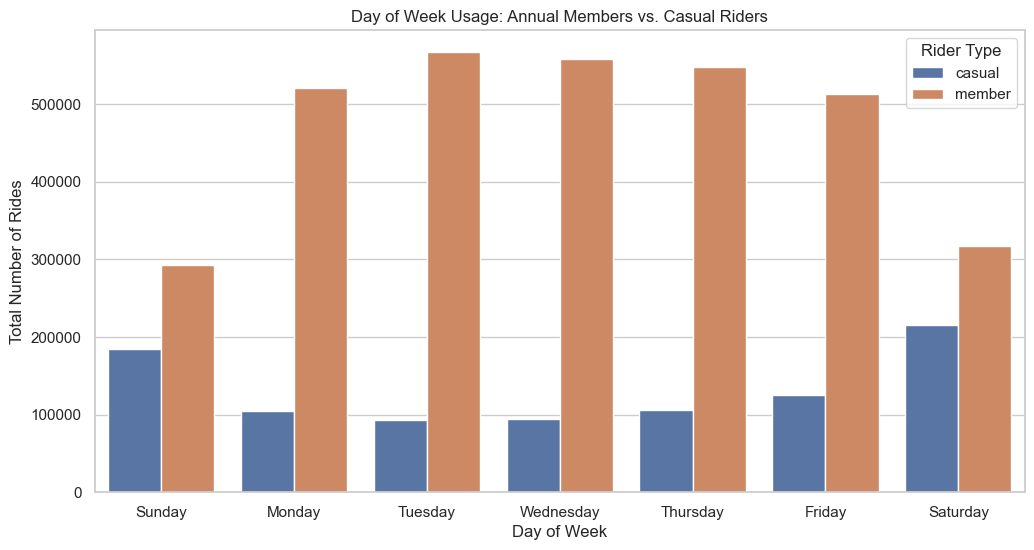

In [20]:
# define the processed data path for the tableau export
tableau_export_path = os.path.join(processed_dir, "tableau_trips_export.csv")

# export only the essential columns to keep file size down for tableau
tableau_cols = ['member_casual', 'month', 'day_of_week', 'hour_clock', 'start_station_name']
all_trips_v2[tableau_cols].to_csv(tableau_export_path, index=False)

# ensure the export directory exists before saving visualization files
os.makedirs('../04_visualizations', exist_ok=True)

# set variable for formats to indicate file types of exported figures
file_formats = ['png', 'pdf']
# this variable is used before each show method to export the chart in multiple formats

# total number of rides by rider type and day of week
# create bar plot with stats_by_type_and_weekday
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    data = stats_by_type_and_weekday,
    x = 'day_of_week',
    y = 'number_of_rides',
    hue = 'member_casual'
)
plt.legend(title = "Rider Type")
plt.title("Day of Week Usage: Annual Members vs. Casual Riders")
plt.xlabel("Day of Week")
plt.ylabel("Total Number of Rides")
# export multiple formats of this plot
for fmt in file_formats:
    plt.savefig(f'../04_visualizations/day_of_week_usage.{fmt}', bbox_inches='tight', dpi = 300)
plt.show()

#### <center>Key Insights from Day of Week Usage</center>
1. **Target High-Volume Weekend Casuals**
   * **The Data:** Casual ridership peaks significantly on Saturday and Sunday, which are the only days their volume approaches that of members.
   * **Recommendation:** Focus marketing efforts (such as digital ads, station signage, or in-app notifications) specifically during the weekend. Highlight how much a "Weekend Warrior" could save over a year by switching from single-ride or day passes to a full membership.
1. **Create a "Commuter Trial" for Weekdays**
   * **The Data:** Casual usage is at its lowest during the workweek (Monday–Wednesday) , while member usage is at its absolute highest.
   * **Recommendation:** To encourage casual riders to use the service for commuting, offer a "Workweek Trial" membership. Providing a discounted or free week of rides for first-time users during these days can help them build a habit of using the bikes for work, making a full annual membership feel more essential.
1. **Introduce a "Weekend-Only" Membership Tier**
   * **The Data:** There is a clear, distinct segment of casual riders who only appear in large numbers on the weekends.
   * **Recommendation:** If a full annual membership feels too expensive for someone who doesn't commute, a lower-cost "Weekend Membership" could capture this segment. This provides a recurring revenue stream from users who would otherwise only pay for sporadic single rides.
1. **Mid-Week "Casual" Incentives**
   * **The Data:** Tuesday and Wednesday represent the lowest engagement days for casual riders.
   * **Recommendation:** Offer "Mid-week Points" or small discounts for casual riders who take trips on these specific days. Increasing their frequency of use during the week makes them more likely to see the value in a year-round, unlimited membership.
1. **Digital Marketing Strategy based on "Commuter vs. Leisure"**
   * **The Data:** The sharp contrast between weekday member dominance and weekend casual spikes  confirms two different user personas.
   * **Recommendation:** Use two different messaging tracks. For the weekend, use "Leisure and Exploration" messaging. For the workweek, use "Beat the Traffic/Eco-Friendly Commute" messaging. Targeted email campaigns should be sent on Friday afternoons to casual riders, reminding them of the convenience of membership for their upcoming weekend plans.

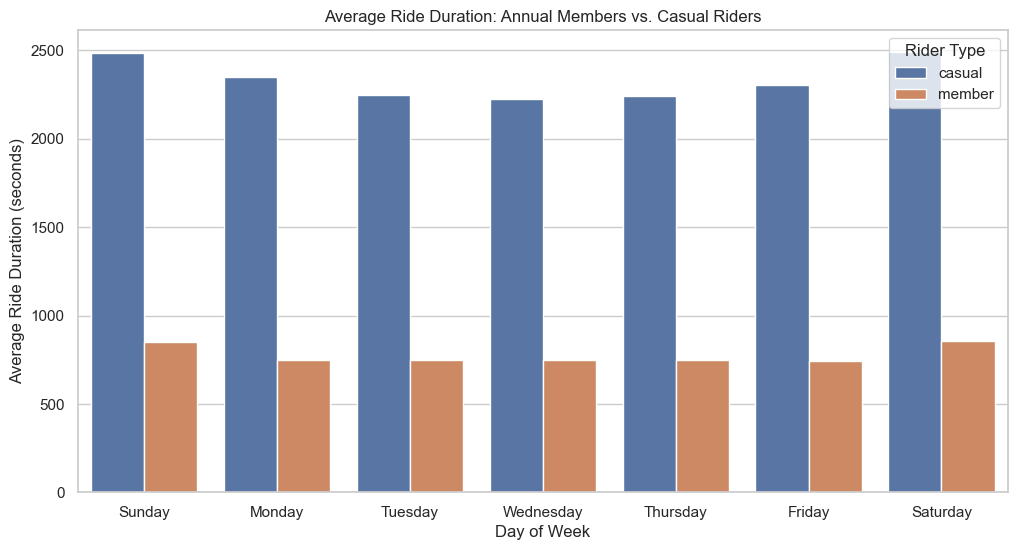

In [21]:
# average ride duration comparison
# create bar plot with stats_by_type_and_weekday
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    data = stats_by_type_and_weekday,
    x = 'day_of_week',
    y = 'average_duration',
    hue = 'member_casual'
)
plt.legend(title = "Rider Type")
plt.title("Average Ride Duration: Annual Members vs. Casual Riders")
plt.xlabel("Day of Week")
plt.ylabel("Average Ride Duration (seconds)")
# export multiple formats of this plot
for fmt in file_formats:
    plt.savefig(f'../04_visualizations/average_ride_duration.{fmt}', bbox_inches='tight', dpi = 300)
plt.show()

#### <center>Key Insights from Average Ride Duration</center>
1. **The "Unlimited Leisure" Campaign**
   * **The Data:** Casual riders have an average ride duration that is 3–4 times longer than annual members, consistently staying between 3,300 and 3,800 seconds (roughly 55–63 minutes).
   * **Recommendation:** Market the annual membership as the "Leisure Pass." Highlight that while casual rides are often long and potentially expensive under a "pay-per-minute" or "single-trip" structure, a membership allows for these long, wandering trips without the pressure of a ticking clock.
1. **Target the Thursday Duration Peak**
   * **The Data:** Casual riders hit their highest average duration of the week on Thursday, nearing the 3,800-second mark.
   * **Recommendation:** "Throwback Thursday" or "Early Weekend" promotions targeted at casual riders. Since they are already taking their longest trips of the week on this day, use in-app notifications on Thursday mornings offering a discount on an annual membership "upgrade" to capture their highest-engagement day.
1. **Duration-Based "Member Perks"**
   * **The Data:** Annual member trips are short and functional, consistently averaging less than 1,000 seconds (about 16 minutes).
   * **Recommendation:** To make membership more attractive to the long-duration casual rider, introduce "Member-Only" benefits that reward longer rides, such as a "First 60 minutes free" policy (if the current casual limit is lower). This directly appeals to the behavior of casual riders who clearly prefer long-form riding.
1. **"Tourist to Local" Conversion:**
   * **The Data:** Casual ride durations are high every single day, including weekdays, which suggests many are likely tourists or non-commuter recreational users.
   * **Recommendation:** Partner with local businesses, parks, or tourist landmarks to offer "Member-Only" discounts. Since casual riders use the bikes for longer durations, they are likely visiting multiple locations; showing how a membership integrates with their leisure lifestyle can bridge the gap from a one-time user to a loyal member.
1. **Commuter Efficiency vs. Recreational Freedom:**
   * **The Data:** There is a massive, consistent gap between the functional, short trips of members and the long, exploratory trips of casual riders across the entire week.
   * **Recommendation:** Use split-testing in digital ads. For casual riders, show imagery of scenic paths and long-duration "slow" travel with a call-to-action about how membership supports "unlimited exploration." This speaks directly to their demonstrated preference for using the bikes as an activity rather than just a utility.

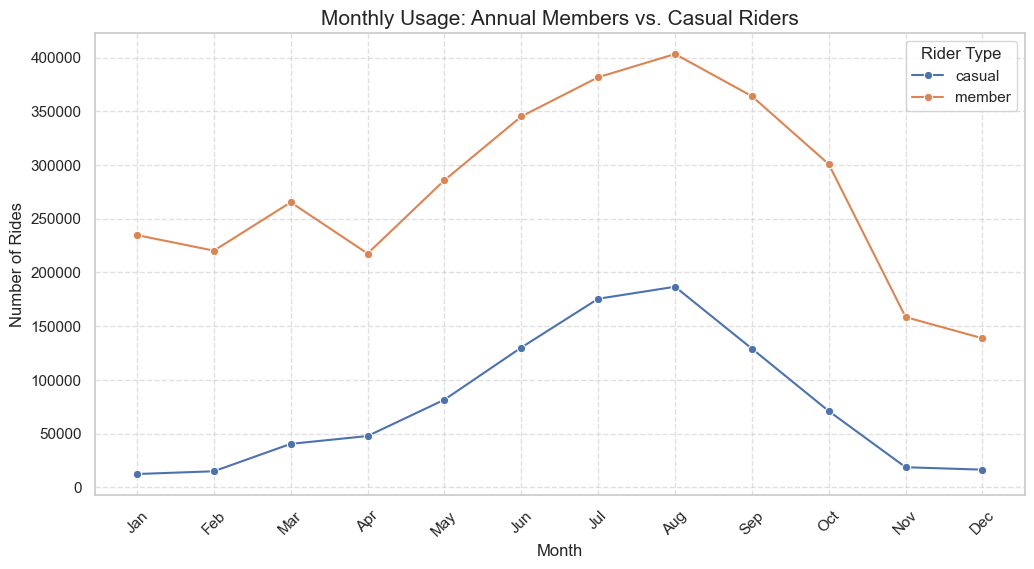

In [22]:
# monthly usage comparison
# create a line chart with stats_by_month
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data = stats_by_month,
    x = 'month',
    y = 'number_of_rides',
    hue = 'member_casual', marker='o')
plt.legend(title = "Rider Type")
plt.title('Monthly Usage: Annual Members vs. Casual Riders', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.xticks(rotation=45) # Rotates dates so they don't overlap
plt.grid(True, linestyle='--', alpha=0.6)
# export multiple formats of this plot
for fmt in file_formats:
    plt.savefig(f'../04_visualizations/monthly_usage.{fmt}', bbox_inches='tight', dpi = 300)
plt.show()

#### <center>Key Insights from Monthly Usage</center>
1. **Seasonal Synchronization of Peaks**
   * **The Data:** Both rider types follow a strong seasonal pattern, with usage peaking for both groups in August (Month 8). While annual members peak at over 400,000 rides, casual riders reach their highest volume at nearly 200,000 rides in the same month.
   * **Recommendation:** Time your primary "conversion" marketing campaigns for late spring and early summer (Months 5–7). Because casual ridership begins its steepest climb during this window, you can capture these users just as they are establishing their summer riding habits and convert them before the August peak.
1. **Winter Resilience vs. Seasonal Abandonment**
   * **The Data:** Annual members show significant resilience in winter, maintaining over 200,000 rides in January and February. Conversely, casual ridership nearly vanishes during the winter months, dropping to its lowest point of the year near the start and end of the calendar.
   * **Recommendation:** Highlight the "all-weather reliability" of the bike-share service in member-focused ads. Since casual riders clearly view the service as a seasonal luxury, demonstrating how members use it as a dependable year-round utility may encourage high-frequency casual riders to switch to a membership for more consistent travel.
1. **The Summer "Casual" Surge:**
   * **The Data:** Casual ridership experiences an explosive growth of approximately 400% between April (Month 4) and August (Month 8). This is the period where the gap between the two rider types is at its narrowest.
   * **Recommendation:** Introduce a "Summer Pass" that automatically rolls over into a discounted annual membership. Since the data shows a massive influx of casual users who only ride during the warm months, a seasonal entry point provides a low-friction way to get them into the system before selling them on the full-year value.
1. **Post-Peak Retention Strategy:**
   * **The Data:** There is a sharp, simultaneous decline in usage for both groups immediately after August (Month 8). However, casual ridership falls off much more steeply than member ridership as the year enters October (Month 10) and beyond.
   * **Recommendation:** Launch a "September Savings" promotion. By offering an incentive to join the annual membership program just as the peak season ends, you can prevent casual riders from completely disengaging during the off-season and secure their loyalty for the following spring.
1. **Comparative Volume Gap:**
   * **The Data:** Annual members consistently maintain a higher volume of rides than casual riders for every single month of the year. Even at the casual riders' peak in August, their volume is still lower than the members' volume in the middle of winter.
   * **Recommendation:** Use this data to validate the stability of the membership model to stakeholders. It proves that the "Member" segment provides a stable, predictable base of revenue and usage that is not nearly as vulnerable to seasonal changes as the "Casual" segment. Marketing should focus on moving casual riders into this more stable "Member" category to protect the company's bottom line during the winter months.

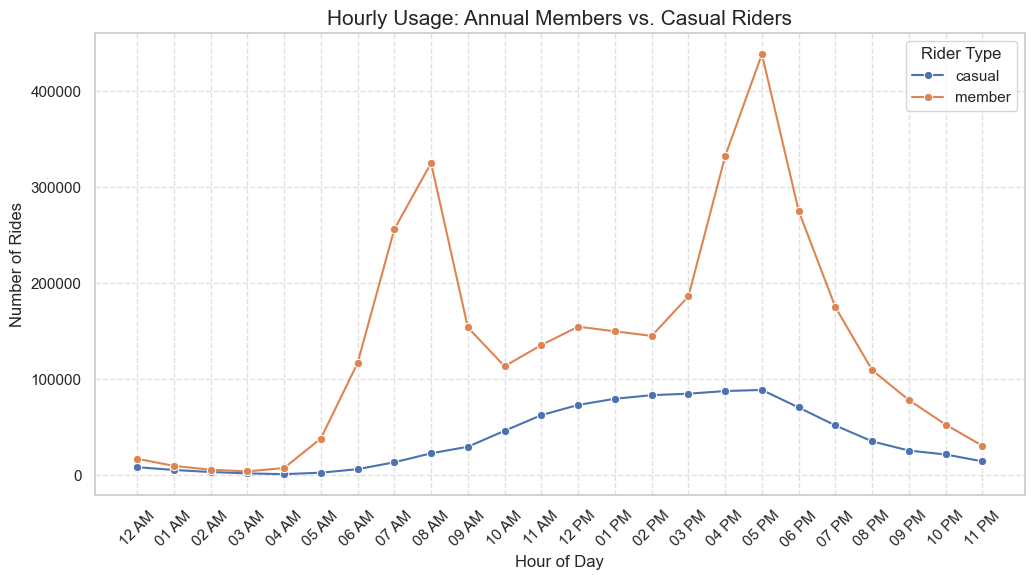

In [23]:
# start station usage top 10
# create a line chart with stats_by_hour
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data = stats_by_hour,
    x='hour_clock',
    y='number_of_rides',
    hue='member_casual', marker='o')
plt.legend(title = "Rider Type")
plt.title('Hourly Usage: Annual Members vs. Casual Riders', fontsize=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.xticks(rotation=45) # Rotates dates so they don't overlap
plt.grid(True, linestyle='--', alpha=0.6)
# export multiple formats of this plot
for fmt in file_formats:
    plt.savefig(f'../04_visualizations/hourly_usage.{fmt}', bbox_inches='tight', dpi = 300)
plt.show()

#### <center>Key Insights from Hourly Usage</center>
1. **The "Double Peak" Commuter Signature**
   * **The Data:** Annual members show a distinct "M-shaped" curve with two major spikes: one around 8 AM (over 300,000 rides) and a significantly larger one at 5 PM (over 400,000 rides). This mirrors standard office "9-to-5" start and end times.
   * **Recommendation:** Market the annual membership as a "Stress-Free Commute" solution. Use the 5 PM peak data to target casual riders who are stuck in traffic or on transit at that exact hour, highlighting how a membership allows them to grab a bike and bypass peak-hour congestion instantly.
1. **Steady Afternoon Growth for Casual Riders**
   * **The Data:** Unlike members, casual riders do not have a morning spike. Instead, their usage grows slowly and steadily throughout the day, reaching a single broad plateau between 3 PM and 6 PM.
   * **Recommendation:** Since casual riders are most active in the late afternoon, this is the prime time for "Happy Hour" or "Sunset Ride" digital promotions. Encouraging casual riders who are already out at 4 PM to sign up for a membership can capture them during their highest-engagement window.
1. **The 5 PM Conversion Window"**
   * **The Data:** 5 PM is the absolute peak for the entire system, where member usage hits its maximum. Casual usage also reaches its highest point of the day at nearly 100,000 rides during this same hour.
   * **Recommendation:** This is your highest-impact moment for conversion. Use push notifications or station-based advertisements at 5 PM specifically. Messaging should focus on "Joining the Community"—showing casual riders that they are part of a massive movement of people heading home via bike.
1. **"Late-Night Safety and Reliability**
   * **The Data:** From 9 PM to 4 AM, both groups show very low usage, but member usage remains slightly higher than casual usage throughout the night.
   * **Recommendation:** Promote membership as a reliable, 24/7 transportation backup. While casual riders might only think of bikes when they see them in the sun, members use them at all hours. Highlighting that a membership is "Always Ready" can appeal to casual riders who may occasionally need a late-night transport option when other methods are unavailable.
1. **Mid-Day "Lunch Break" Opportunity"**
   * **The Data:** Between the two member peaks, there is a relative dip at 10 AM, followed by a sustained "mid-day hump" of around 150,000 rides between 11 AM and 2 PM. Casual ridership is also steadily rising during this period.
   * **Recommendation:** Target casual riders taking "mid-day" trips with messaging about the convenience of using bikes for errands or lunch runs. Framing the membership as a tool for "Quick City Trips" can help casual riders see the utility of the service beyond just a weekend or afternoon activity.

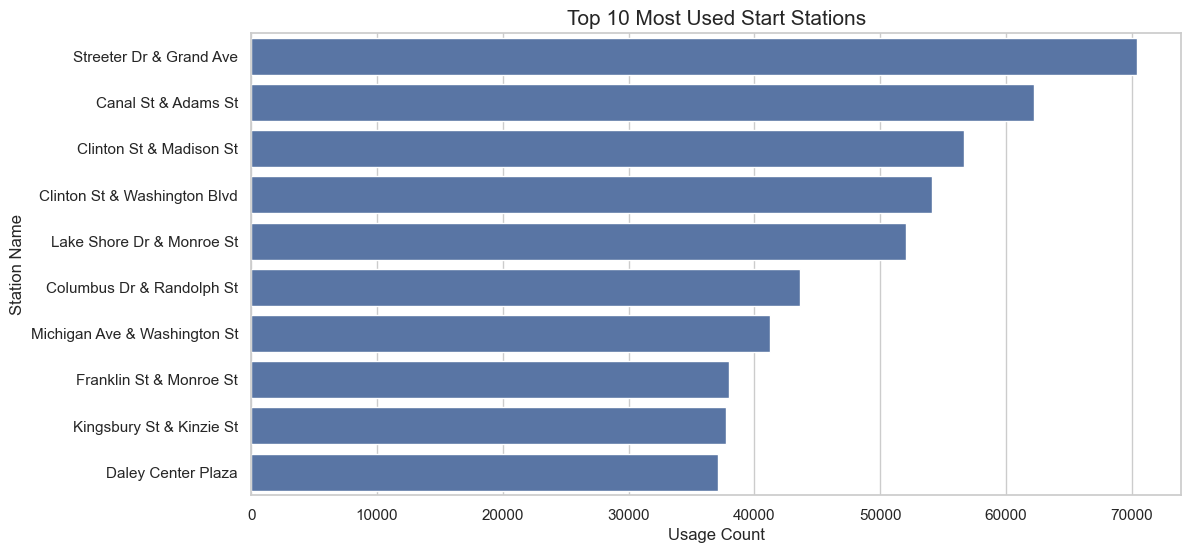

In [24]:
# hourly usage comparison
# create a horizontal bar chart with top_10_stations
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    y = top_10_stations.index,
    x = top_10_stations.values
)
# plt.legend(title = "Rider Type")
plt.title('Top 10 Most Used Start Stations', fontsize=15)
plt.xlabel('Usage Count', fontsize=12)
plt.ylabel('Station Name', fontsize=12)
# export multiple formats of this plot
for fmt in file_formats:
    plt.savefig(f'../04_visualizations/top_10_stations.{fmt}', bbox_inches='tight', dpi = 300)
plt.show()

#### <center>Key Insights from Top 10 Stations</center>
**Recommendation:** Use these stations to place physical ads since they are the most used start stations.

## Phase 6: Act

### Final Recommendations
Based on the analysis of Cyclistic’s historical trip data, I recommend the following three strategies to convert casual riders into annual members:

1. **Introduce a "Weekend Warrior" Membership Tier:**
    * **The Insight:** Casual riders dominate weekend usage with significantly longer ride durations, suggesting a leisure-focused user persona.
    * **The Action:** Create a lower-cost membership specifically for Friday–Sunday. This captures the high-volume weekend segment who may be intimidated by the cost of a full annual pass but are currently overpaying through single-ride fees.
1. **Digital "Commuter Conversion" Campaign:**
    * **The Insight:** Member usage peaks sharply during traditional 8 AM and 5 PM rush hours, while casual ridership is lowest during the workweek.
    * **The Action:** Launch a targeted digital campaign during the summer months (peak ridership) focusing on the "Stress-Free Commute." Use split-testing for ads: show "Eco-Friendly/Cost-Savings" messaging on weekdays and "Leisure/Exploration" messaging on weekends.
1. **Station-Specific Seasonal Promotions:**
    * **The Insight:** Peak ridership occurs from May to August, with top stations centered around high-traffic leisure areas like Montrose Harbor.
    * **The Action:** Increase physical presence (signage/pop-up events) at the Top 10 most used stations during the summer. Offer an "Immediate Conversion" discount: a QR code on the bike docks that gives casual riders $20 off an annual membership if they sign up before their current trip ends.

### Conclusion
Casual riders and annual members use Cyclistic bikes for fundamentally different purposes—members for utility and commuting, and casual riders for long-duration leisure. By creating a bridge between these two behaviors—specifically through a weekend-specific tier and a "commuter trial"—Cyclistic can turn "one-time" leisure users into long-term, profitable annual members.

**Technical Next Steps:** To further refine this analysis, I recommend integrating weather data and user demographic data. This would allow us to determine if "Casual" spikes are solely weekend-dependent or if they correlate strongly with specific temperature thresholds, allowing for even more precise ad-spend timing.